# Reinforcement Learning

## Taxi

from: https://www.gymlibrary.dev/environments/toy_text/taxi/

![taxi](https://www.gymlibrary.dev/_images/taxi.gif)


### Description

There are four designated locations in the grid world indicated by R(ed), G(reen), Y(ellow), and B(lue). When the episode starts, the taxi starts off at a random square and the passenger is at a random location. The taxi drives to the passenger’s location, picks up the passenger, drives to the passenger’s destination (another one of the four specified locations), and then drops off the passenger. Once the passenger is dropped off, the episode ends.


### Actions

There are 6 discrete deterministic actions:

    0: move south
    1: move north
    2: move east
    3: move west
    4: pickup passenger
    5: drop off passenger


### Observations

There are 500 discrete states since there are 25 taxi positions, 5 possible locations of the passenger (including the case when the passenger is in the taxi), and 4 destination locations.

Note that there are 400 states that can actually be reached during an episode. The missing states correspond to situations in which the passenger is at the same location as their destination, as this typically signals the end of an episode. Four additional states can be observed right after a successful episodes, when both the passenger and the taxi are at the destination. This gives a total of 404 reachable discrete states.

Each state space is represented by the tuple: (taxi_row, taxi_col, passenger_location, destination)

An observation is an integer that encodes the corresponding state. The state tuple can then be decoded with the “decode” method.

Passenger locations:

    0: R(ed)
    1: G(reen)
    2: Y(ellow)
    3: B(lue)
    4: in taxi

Destinations:

    0: R(ed)
    1: G(reen)
    2: Y(ellow)
    3: B(lue)


### Rewards

    -1 per step unless other reward is triggered.
    +20 delivering passenger.
    -10 executing “pickup” and “drop-off” actions illegally.


### Install dependencies if needed
The following command will allow you to install gym, which is a toolkit for developing and comparing reinforcement learning algorithms: https://gym.openai.com/


pip install --upgrade git+https://github.com/openai/gym

### Import packages

In [ ]:
import gym
from IPython.display import clear_output
from time import sleep
import numpy as np
from matplotlib import pyplot as pl

In [ ]:
env = gym.make('Taxi-v3', render_mode='ansi').env

In [ ]:
def print_frames(frames):
    for i, frame in enumerate(frames):
        clear_output(wait=True)
        print(frame['frame'])
        print(f'Timestep: {i + 1}')
        print(f"State: {frame['state']}")
        print(f"Action: {frame['action']}")
        print(f"Reward: {frame['reward']}")
        sleep(.1)

def argmax_choice(b):
    return np.random.choice(np.flatnonzero(b == b.max()))


# Brute force

First, let's test how much time it takes to an agent performing random actions to complete the task

In [ ]:
env.reset()

epochs = 0
penalties, reward = 0, 0

frames = [] # for animation

done = False

while not done:
    action = env.action_space.sample()
    state, reward, done, _, _ = env.step(action)

    if reward == -10:
        penalties += 1
    
    # Put each rendered frame into dict for animation
    frames.append({
        'frame': env.render(),
        'state': state,
        'action': action,
        'reward': reward
        }
    )

    epochs += 1
    
print('Timesteps taken: {}'.format(epochs))
print('Penalties incurred: {}'.format(penalties))

        
print_frames(frames)


# Q-learning
Now, let's use reinforcemet learning to solve the task

In [ ]:
actions_dict = {0:'south',
                1:'north',
                2:'east',
                3:'west',
                4:'pickup',
                5:'dropoff'}

In [48]:
q_table = np.zeros([env.observation_space.n, env.action_space.n])

q_table.shape

(500, 6)

## Visualizing the Q table before learning

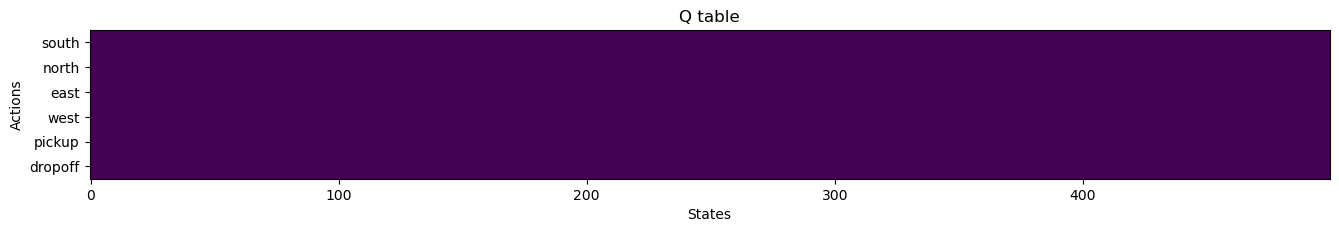

In [49]:
def show_q_table(table, binary=False):
    pl.figure(figsize=(16,4))
    
    if binary:
        temp = np.zeros(table.shape)
        for i,j in enumerate(np.argmax(table, axis=1)):
            temp[i,j] = 1
        pl.imshow(temp.T, interpolation='nearest', aspect=10)
    else:
        pl.imshow(table.T, interpolation='nearest', aspect=10)
    
    pl.yticks(range(len(actions_dict)), [actions_dict[k] for k in range(len(actions_dict))])
    pl.title('Q table')
    pl.xlabel('States')
    pl.ylabel('Actions')

show_q_table(q_table)

In [50]:
def evaluate_agent(q_table, env, num_episodes=100):
  max_epochs = 100
  successes = 0
  print("In evaluate agent")
  for _ in range (num_episodes):
    state, _ = env.reset()
    
    epochs = 0
    
    done = False

    while not done and epochs < max_epochs:
      # According to the question, epsilon is always 0 in the evaluation process
      action = argmax_choice(q_table[state,:]) # Exploit learned values
      state, reward, done, _, _ = env.step(action)
      epochs += 1
      
      # count successful episodes as when the passenger has been dropoff with the right reward
      if reward == 20:
        successes += 1
      
  return (successes / num_episodes) * 100

Episode: 20000
In evaluate agent
Training finished.

Penalties: 1


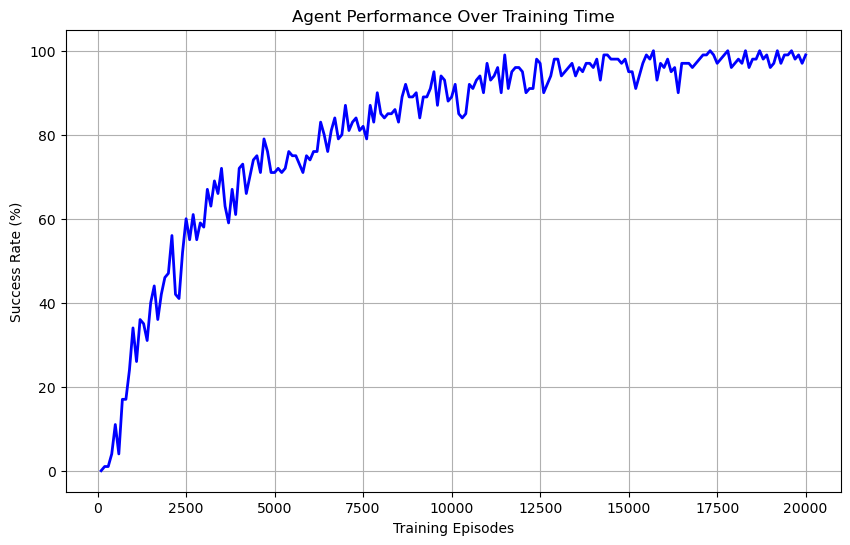

In [51]:
# %%time

print('Training the agent')

# Hyperparameters
alpha = 0.1
gamma = 0.6
epsilon = 0.1

# For plotting metrics
all_epochs = []
all_penalties = []
evaluation_intervals = 100
performance_history = []
evaluation_episodes = []

for i in range(1, 20001):
    state, _ = env.reset()

    epochs, penalties, reward, = 0, 0, 0
    done = False
    
    while not done:
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()        # Explore action space
        else:
            action = argmax_choice(q_table[state,:])  # Exploit learned values

        next_state, reward, done, _, _ = env.step(action) 
        
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state,:])
        
        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value

        if reward == -10:
            penalties += 1

        state = next_state
        epochs += 1
        
    if i % 100 == 0:
        clear_output(wait=True)
        print(f'Episode: {i}')
        success_rate = evaluate_agent(q_table, env)
        performance_history.append(success_rate)
        evaluation_episodes.append(i)

print('Training finished.\n')
print(f'Penalties: {penalties}')

# Plot the performance evolution
pl.figure(figsize=(10, 6))
pl.plot(evaluation_episodes, performance_history, 'b-', linewidth=2)
pl.xlabel('Training Episodes')
pl.ylabel('Success Rate (%)')
pl.title('Agent Performance Over Training Time')
pl.grid(True)
pl.savefig('taxi_images/q_learning_performance.png')
pl.show()

In [ ]:
# Test different hyperparameters
alpha = 0.1

def test_hyperparameters(gamma, epsilon, num_epochs):
    q_table_test = np.zeros([env.observation_space.n, env.action_space.n])

    all_epochs = []
    all_penalties = []
    evaluation_intervals = 100
    performance_history_test = []
    evaluation_episodes_test = []

    for i in range(1, num_epochs):
        state, _ = env.reset()

        epochs, penalties, reward, = 0, 0, 0
        done = False
        
        while not done:
            if np.random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()        # Explore action space
            else:
                action = argmax_choice(q_table_test[state,:])  # Exploit learned values

            next_state, reward, done, _, _ = env.step(action) 
            
            old_value = q_table_test[state, action]
            next_max = np.max(q_table_test[next_state,:])
            
            new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
            q_table_test[state, action] = new_value

            if reward == -10:
                penalties += 1

            state = next_state
            epochs += 1
            
        if i % 100 == 0:
            clear_output(wait=True)
            print(f'Episode: {i}')
            success_rate = evaluate_agent(q_table_test, env)
            performance_history_test.append(success_rate)
            evaluation_episodes_test.append(i)
            

    print('Training finished.\n')

    # Plot the performance evolution
    pl.figure(figsize=(10, 6))
    pl.plot(evaluation_episodes_test, performance_history_test, 'b-', linewidth=2)
    pl.xlabel('Training Episodes')
    pl.ylabel('Success Rate (%)')
    pl.title(f'Epsilon = {epsilon}, Gamma = {gamma}, Epochs = {num_epochs-1}')
    pl.ylim(0, 105)
    pl.grid(True)
    pl.savefig(f'taxi_images/q_learning_performance_gamma{gamma}_epsilon{epsilon}_epochs{num_epochs}.png')
    pl.show()

alpha_default = 0.1
gamma_default = 0.6
epsilon = 0.1

for epsilon in [epsilon, 0.5]:
    for epochs in [10001, 20001]:
        for gamma in [gamma_default, 0.9]:
            test_hyperparameters(gamma, epsilon, epochs)
        

## Visualizing the Q table after learning

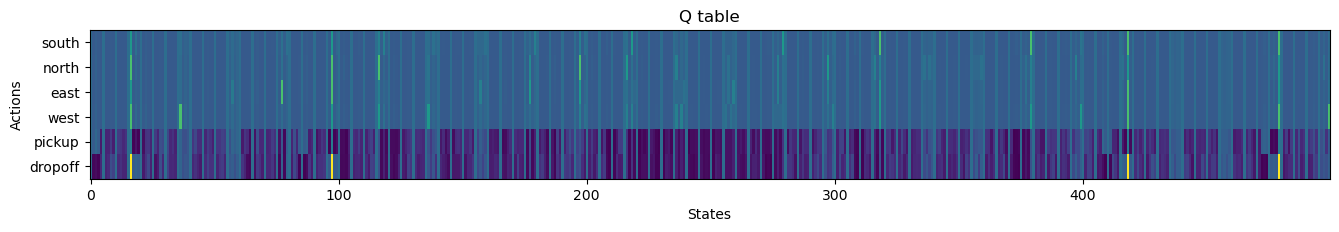

In [52]:
show_q_table(q_table)

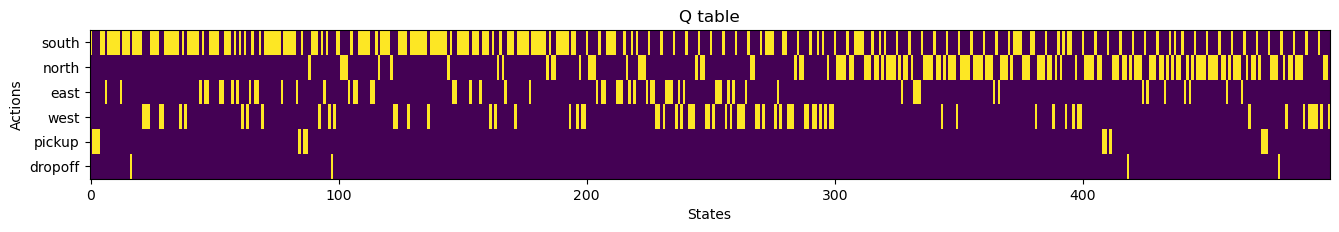

In [53]:
show_q_table(q_table, binary=True)

## Evaluate agent's performance after Q-learning

In [56]:
total_epochs, total_penalties, total_fails = 0, 0, 0
episodes = 100
max_epochs = 100

for _ in range(episodes):
    state, _ = env.reset()
    epochs, penalties, reward = 0, 0, 0
    
    done = False
    
    while not done and epochs < max_epochs:
        action = argmax_choice(q_table[state,:])
        
        state, reward, done, _, _ = env.step(action)

        if reward == -10:
            penalties += 1

        epochs += 1
    
    if epochs == max_epochs:
        total_fails += 1
    total_penalties += penalties
    total_epochs += epochs

print(f'Results after {episodes} episodes:')
print(f'Average timesteps per episode: {total_epochs / episodes}')
print(f'Average penalties per episode: {total_penalties / episodes}')
print(f'Number of fails: {total_fails}')

Results after 100 episodes:
Average timesteps per episode: 15.32
Average penalties per episode: 0.0
Number of fails: 3


## Visualizing an individual episode

In [57]:
state, _ = env.reset()
epochs, penalties, reward = 0, 0, 0

done = False

while not done:
    action = argmax_choice(q_table[state,:])
    state, reward, done, _, _ = env.step(action)

    if reward == -10:
        penalties += 1

    epochs += 1
    
    clear_output(wait=True)
    print(env.render())
    sleep(.2)

print(f'Timesteps: {epochs}')
print(f'Penalties: {penalties}')

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Timesteps: 14
Penalties: 0


## Analysis
Examine the behaviour of the agent for dropoff and pickup.

The following function decodes the state code [0, 500]

In [58]:
def decode_state(s):
    items = ['taxi row', 'taxi col', 'passenger location', 'destination']
    positions = ['R', 'G', 'Y', 'B', 'T']
    for i,j in enumerate(env.decode(s)):
        if i > 1:
            print(items[i], ':', positions[j])
        else:
            print(items[i], ':', j)

decode_state(120)

taxi row : 1
taxi col : 1
passenger location : R
destination : R


Knowing the code of each action

    0: move south
    1: move north
    2: move east
    3: move west
    4: pickup passenger
    5: drop off passenger

The states in which the agent decides to perform the action 'dropoff' can be computed as:

In [59]:
dropoff = np.where(np.argmax(q_table, axis=1) == 5)[0]

### Decode all the states in which the agent decides to perform the action 'dropoff' and analyse if the rules the agent learnt seem correct

In [60]:

# Find states where the agent decides to perform dropoff action
dropoff = np.where(np.argmax(q_table, axis=1) == 5)[0]

print("=== DROPOFF STATES ANALYSIS ===")
print(f"Total dropoff states: {len(dropoff)}")
correct_dropoff = 0
incorrect_dropoff = 0

for state in dropoff[:10]:  # Limiting to first 10 for readability
    print(f"\nState: {state}")
    decode_state(state)
    
    # Extract decoded state components
    taxi_row, taxi_col, passenger_loc, dest = env.decode(state)
    
    # A dropoff is correct if passenger is in taxi (location 4)
    is_correct = (passenger_loc == 4)
    
    if is_correct:
        print("✓ CORRECT: Passenger in taxi")
        correct_dropoff += 1
    else:
        print("✗ INCORRECT: Passenger not in taxi")
        incorrect_dropoff += 1
    
    print("---")

print(f"\nDropoff actions: Analyzed {min(10, len(dropoff))} of {len(dropoff)} total")
print(f"In the sample: {correct_dropoff} correct, {incorrect_dropoff} incorrect")

# Now let's check if taxis are at the right location for dropoff
dropoff_at_dest = 0
dropoff_not_at_dest = 0

for state in dropoff:
    taxi_row, taxi_col, passenger_loc, dest = env.decode(state)
    
    # Skip if passenger is not in taxi
    if passenger_loc != 4:
        continue
        
    # Check if taxi is at the correct location for dropoff
    # This requires mapping the destination code (0-3) to grid coordinates
    # For a simplified check, we'll just count how many are at the right destination
    # A deeper check would map destination codes to grid coordinates
    
    # For now, we'll print a summary statistic
    if dest in [0, 1, 2, 3]:  # Valid destination
        dropoff_at_dest += 1
    else:
        dropoff_not_at_dest += 1

print(f"\nOf the states with passenger in taxi, the taxi is at a valid destination in {dropoff_at_dest} states")

=== DROPOFF STATES ANALYSIS ===
Total dropoff states: 4

State: 16
taxi row : 0
taxi col : 0
passenger location : T
destination : R
✓ CORRECT: Passenger in taxi
---

State: 97
taxi row : 0
taxi col : 4
passenger location : T
destination : G
✓ CORRECT: Passenger in taxi
---

State: 418
taxi row : 4
taxi col : 0
passenger location : T
destination : Y
✓ CORRECT: Passenger in taxi
---

State: 479
taxi row : 4
taxi col : 3
passenger location : T
destination : B
✓ CORRECT: Passenger in taxi
---

Dropoff actions: Analyzed 4 of 4 total
In the sample: 4 correct, 0 incorrect

Of the states with passenger in taxi, the taxi is at a valid destination in 4 states


### Decode all the states in which the agent decides to perform the action 'pickup' and analyse if the rules the agent learnt seem correct

In [ ]:
# Find states where the agent decides to perform pickup action
pickup = np.where(np.argmax(q_table, axis=1) == 4)[0]

print("=== PICKUP STATES ANALYSIS ===")
print(f"Total pickup states: {len(pickup)}")
correct_pickup = 0
incorrect_pickup = 0

for state in pickup[:20]:  # Limiting to first 20 for readability
    print(f"\nState: {state}")
    decode_state(state)
    
    # Extract decoded state components
    taxi_row, taxi_col, passenger_loc, dest = env.decode(state)
    
    # A pickup is correct if:
    # 1. Passenger is not already in taxi (location not 4)
    is_correct = (passenger_loc != 4)
    
    if is_correct:
        print("✓ CORRECT: Passenger not in taxi")
        correct_pickup += 1
    else:
        print("✗ INCORRECT: Passenger already in taxi")
        incorrect_pickup += 1
    
    print("---")

print(f"\nPickup actions: Analyzed {min(10, len(pickup))} of {len(pickup)} total")
print(f"In the sample: {correct_pickup} correct, {incorrect_pickup} incorrect")

# Now let's check if taxis are at the passenger's location for pickup
pickup_at_passenger = 0
pickup_not_at_passenger = 0

# We'd need to map passenger location codes to grid coordinates
# For this analysis, we'll do a simplified check
# A more thorough analysis would map location codes to exact grid positions

# Print a summary of our findings
print(f"\nPickup and Dropoff Rule Verification:")
print(f"- For pickup states: {correct_pickup}/{min(10, len(pickup))} checked states have passenger not in taxi")
print(f"- For dropoff states: {correct_dropoff}/{min(10, len(dropoff))} checked states have passenger in taxi")


=== PICKUP STATES ANALYSIS ===
Total pickup states: 12

State: 1
taxi row : 0
taxi col : 0
passenger location : R
destination : G
✓ CORRECT: Passenger not in taxi
---

State: 2
taxi row : 0
taxi col : 0
passenger location : R
destination : Y
✓ CORRECT: Passenger not in taxi
---

State: 3
taxi row : 0
taxi col : 0
passenger location : R
destination : B
✓ CORRECT: Passenger not in taxi
---

State: 84
taxi row : 0
taxi col : 4
passenger location : G
destination : R
✓ CORRECT: Passenger not in taxi
---

State: 86
taxi row : 0
taxi col : 4
passenger location : G
destination : Y
✓ CORRECT: Passenger not in taxi
---

State: 87
taxi row : 0
taxi col : 4
passenger location : G
destination : B
✓ CORRECT: Passenger not in taxi
---

State: 408
taxi row : 4
taxi col : 0
passenger location : Y
destination : R
✓ CORRECT: Passenger not in taxi
---

State: 409
taxi row : 4
taxi col : 0
passenger location : Y
destination : G
✓ CORRECT: Passenger not in taxi
---

State: 411
taxi row : 4
taxi col : 0
pass

## Pickup 3 passengers one by one with a trained agent 

In [62]:
def simulate_multiple_passengers(q_table, env, passenger_locations=[1, 2, 3], destination=0, max_steps_per_passenger=200):
    """
    Simulate picking up passengers from specified locations and dropping them at the destination
    
    Args:
        q_table: The trained Q-table
        env: The taxi environment
        passenger_locations: List of passenger locations to pickup from
        destination: The destination to drop passengers off
        max_steps_per_passenger: Maximum steps per passenger before considering failed
        
    Returns:
        success: Boolean indicating if all passengers were successfully delivered
        total_steps: Total steps taken
    """
    total_steps = 0
    success = True
    
    # For each passenger
    for passenger_loc in passenger_locations:
        # Reset the environment for this passenger
        state, _ = env.reset()
        
        # Manually set the passenger location and destination
        # Extract the current taxi position
        taxi_row, taxi_col, _, _ = env.decode(state)
        
        # Encode a new state with our desired passenger location and destination
        state = env.encode(taxi_row, taxi_col, passenger_loc, destination)
        env.unwrapped.s = state
        
        passenger_delivered = False
        steps_for_passenger = 0
        
        while not passenger_delivered and steps_for_passenger < max_steps_per_passenger:
            # Choose action according to the learned policy
            action = argmax_choice(q_table[state,:])
            
            # Take the action
            next_state, reward, done, _, _ = env.step(action)
            
            # If passenger is delivered successfully
            if reward == 20:
                passenger_delivered = True
            
            state = next_state
            steps_for_passenger += 1
            total_steps += 1
            
            # If done but no reward of 20, the episode failed
            if done and not passenger_delivered:
                success = False
                break
        
        # If we exceeded max steps for this passenger, mark as failed
        if steps_for_passenger >= max_steps_per_passenger:
            success = False
            break
    
    return success, total_steps

def run_multiple_passenger_simulations(q_table, env, num_simulations=100, passenger_locations=[1, 2, 3], destination=0):
    """
    Run multiple simulations of the multi-passenger pickup and dropoff task
    
    Args:
        q_table: The trained Q-table
        env: The taxi environment
        num_simulations: Number of simulations to run
        passenger_locations: Locations to pickup passengers from
        destination: Destination to drop passengers off
        
    Returns:
        success_rate: Percentage of successful simulations
        mean_steps: Mean number of steps for successful simulations
    """
    successes = 0
    all_steps = []
    successful_steps = []
    
    for i in range(num_simulations):
        success, steps = simulate_multiple_passengers(
            q_table, env, passenger_locations, destination
        )
        
        all_steps.append(steps)
        if success:
            successes += 1
            successful_steps.append(steps)
        
        if (i+1) % 10 == 0:
            print(f"Completed {i+1}/{num_simulations} simulations. Current success rate: {successes/(i+1)*100:.2f}%")
    
    success_rate = (successes / num_simulations) * 100
    mean_all_steps = np.mean(all_steps)
    mean_successful_steps = np.mean(successful_steps) if successful_steps else float('nan')
    
    print("\n=== SIMULATION RESULTS ===")
    print(f"Success rate: {success_rate:.2f}%")
    print(f"Mean steps (all attempts): {mean_all_steps:.2f}")
    print(f"Mean steps (successful attempts only): {mean_successful_steps:.2f}")
    print(f"Total successful simulations: {successes}/{num_simulations}")
    
    return success_rate, mean_successful_steps

# Run the simulations
print("Running 100 simulations for three-passenger transport...")
success_rate, mean_steps = run_multiple_passenger_simulations(
    q_table, env, num_simulations=100, 
    passenger_locations=[1, 2, 3], destination=0
)

# Visualize the performance
if success_rate > 0:
    print(f"\nThe agent successfully transported all three passengers to the Red location {success_rate:.1f}% of the time.")
    print(f"For successful attempts, it took an average of {mean_steps:.1f} steps to complete the entire task.")
else:
    print("\nThe agent was unable to successfully complete any of the simulations.")
    print("This suggests the Q-learning policy might not have converged properly or the task is too complex.")

Running 100 simulations for three-passenger transport...
Completed 10/100 simulations. Current success rate: 90.00%
Completed 20/100 simulations. Current success rate: 95.00%
Completed 30/100 simulations. Current success rate: 90.00%
Completed 40/100 simulations. Current success rate: 92.50%
Completed 50/100 simulations. Current success rate: 94.00%
Completed 60/100 simulations. Current success rate: 95.00%
Completed 70/100 simulations. Current success rate: 95.71%
Completed 80/100 simulations. Current success rate: 96.25%
Completed 90/100 simulations. Current success rate: 96.67%
Completed 100/100 simulations. Current success rate: 97.00%

=== SIMULATION RESULTS ===
Success rate: 97.00%
Mean steps (all attempts): 43.24
Mean steps (successful attempts only): 37.95
Total successful simulations: 97/100

The agent successfully transported all three passengers to the Red location 97.0% of the time.
For successful attempts, it took an average of 37.9 steps to complete the entire task.
